<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA2/TALLER5/E5_NeuralNetworksKerasNLP_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Excercise 5**
## NLP with Keras

**INTEGRANTES:**

Luis Alejandro Garzón Ramirez

Zorayda Acevedo Jimenez

Yulieth Danitza Aguillón Ortega

Use keras framework to solve the below exercises.


In [1]:
pip install tensorflow==2.12.0 keras==2.12.0 numpy==1.23.5 --no-cache-dir


INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 185.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 64.2 MB/s eta 0:00:00


In [2]:
!pip install wget
!pip install livelossplot --quiet
!pip install gensim --quiet

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=f59facec54d4f276d9e5732c7c72de78300dedf0601d158f2d3ec846f9824c9c
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 11.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.5 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is i

Importar librerias necesarias

In [1]:
import pandas as pd
import numpy as np
import wget
import random
import os
from zipfile import ZipFile

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from nltk.stem import WordNetLemmatizer
import string

from sklearn.model_selection import train_test_split

import tensorflow as tf
from keras import backend as K
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout, GlobalAveragePooling1D, Flatten, BatchNormalization
from keras.layers import Embedding
from keras.utils import pad_sequences
from livelossplot import PlotLossesKeras

import matplotlib.pyplot as plt

import gensim
from gensim.models import Word2Vec
import warnings

import nltk
warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## 5.1 Predict rating of a movie using Keras

**Exercise:** Use keras framework to predict rating.

In [2]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

Extrae la columna 'plot' (sinopsis de películas). Crea una variable binaria y para clasificar las películas en alta (1) o baja (0) calificación según si su rating es mayor o igual al promedio.

In [3]:
plots = dataTraining['plot']
y = (dataTraining['rating'] >= dataTraining['rating'].mean()).astype(int)

In [4]:
plots

,plot
3107,most is the story of a single father who takes...
900,a serial killer decides to teach the secrets o...
6724,"in sweden , a female blackmailer with a disfi..."
4704,"in a friday afternoon in new york , the presi..."
2582,"in los angeles , the editor of a publishing h..."
...,...
8417,""" our marriage , their wedding . "" it ' s l..."
1592,"the wandering barbarian , conan , alongside ..."
1723,"like a tale spun by scheherazade , kismet fol..."
7605,"mrs . brisby , a widowed mouse , lives in a..."


Revisión general de datos

In [5]:
plots.shape

(7895,)

In [6]:
plots.describe()

,plot
count,7895
unique,7894
top,an evil genius in a flying fortress is trying ...
freq,2


Rating por cada una de los codigos de peliculas

In [7]:
y

,rating
3107,1
900,0
6724,1
4704,1
2582,1
...,...
8417,0
1592,0
1723,0
7605,1


In [8]:
y.head()

,rating
3107,1
900,0
6724,1
4704,1
2582,1


Se extrae la columna "plot" del DataFrame dataTraining y la almacena en la variable X.

In [9]:
X = dataTraining['plot']

In [10]:
X.head()

,plot
3107,most is the story of a single father who takes...
900,a serial killer decides to teach the secrets o...
6724,"in sweden , a female blackmailer with a disfi..."
4704,"in a friday afternoon in new york , the presi..."
2582,"in los angeles , the editor of a publishing h..."


## Data Precosessing

- Remove stopwords
- Lowercase
- split the text in words
- pad_sequences

# Remove stopwords y Lowercase

In [11]:
import nltk
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_lemm(text):
    tokens = nltk.word_tokenize(text.lower()) #Lowercase
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words] #Remove Stopwords
    tokens = [lemmatizer.lemmatize(token) for token in tokens] #Lemmatizing
    return ' '.join(tokens)

X = X.apply(preprocess_text_lemm)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [12]:
X.head()

,plot
3107,story single father take eight year old son wo...
900,serial killer decides teach secret satisfying ...
6724,sweden female blackmailer disfiguring facial s...
4704,friday afternoon new york president tredway co...
2582,los angeles editor publishing house carol hunn...


# Split the text in words

In [13]:
from collections import Counter

# Combine all plots into a single string
all_text = ' '.join(X)

# Tokenize the string into individual words
words = all_text.split()

# Create a vocabulary using Counter
vocabulary = Counter(words)

# Convert the Counter object to a dictionary
# with words as keys and frequencies as values
vocabulary_dict = dict(vocabulary)

# If you need indices for each word:
vocabulary_with_index = {word: index + 1 for index, word in enumerate(vocabulary_dict)}

In [14]:
vocabulary_dict

{'story': 1072,
 'single': 169,
 'father': 1468,
 'take': 1624,
 'eight': 102,
 'year': 2085,
 'old': 1254,
 'son': 990,
 'work': 1166,
 'railroad': 31,
 'drawbridge': 2,
 'bridge': 51,
 'tender': 9,
 'day': 1308,
 'boy': 752,
 'meet': 1246,
 'woman': 1339,
 'boarding': 36,
 'train': 262,
 'drug': 496,
 'abuser': 5,
 'go': 1753,
 'engine': 21,
 'room': 295,
 'tell': 893,
 'stay': 349,
 'edge': 54,
 'nearby': 82,
 'lake': 84,
 'ship': 267,
 'come': 1120,
 'lifted': 5,
 'though': 226,
 'supposed': 78,
 'arrive': 117,
 'hour': 183,
 'later': 604,
 'happens': 157,
 'see': 988,
 'try': 1098,
 'warn': 22,
 'able': 395,
 'oncoming': 6,
 'approach': 90,
 'fall': 736,
 'gear': 14,
 'attempting': 34,
 'lower': 33,
 'leaving': 190,
 'horrific': 35,
 'choice': 125,
 'crushing': 11,
 'people': 847,
 'completely': 87,
 'oblivious': 11,
 'fact': 210,
 'died': 176,
 'trying': 504,
 'save': 448,
 'addict': 36,
 'happened': 156,
 'look': 419,
 'window': 67,
 'movie': 512,
 'end': 756,
 'man': 1929,
 'wa

In [15]:
vocabulary

Counter({'story': 1072,
         'single': 169,
         'father': 1468,
         'take': 1624,
         'eight': 102,
         'year': 2085,
         'old': 1254,
         'son': 990,
         'work': 1166,
         'railroad': 31,
         'drawbridge': 2,
         'bridge': 51,
         'tender': 9,
         'day': 1308,
         'boy': 752,
         'meet': 1246,
         'woman': 1339,
         'boarding': 36,
         'train': 262,
         'drug': 496,
         'abuser': 5,
         'go': 1753,
         'engine': 21,
         'room': 295,
         'tell': 893,
         'stay': 349,
         'edge': 54,
         'nearby': 82,
         'lake': 84,
         'ship': 267,
         'come': 1120,
         'lifted': 5,
         'though': 226,
         'supposed': 78,
         'arrive': 117,
         'hour': 183,
         'later': 604,
         'happens': 157,
         'see': 988,
         'try': 1098,
         'warn': 22,
         'able': 395,
         'oncoming': 6,
         'approach'

In [16]:
len(vocabulary)

34477

# Pad_sequences

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Assuming X contains your movie plot strings
# Create a tokenizer to convert words to integers
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)  # Fit the tokenizer on your text data

# Convert text sequences to numerical sequences
X_numerical = tokenizer.texts_to_sequences(X)
max_len = max(len(sublist) for sublist in X_numerical)

# Apply padding to the numerical sequences
X_pad = pad_sequences(X_numerical, maxlen=max_len)

In [18]:
max_len

818

In [19]:
X_pad

array([[    0,     0,     0, ...,  4330,  7664,    59],
       [    0,     0,     0, ...,  1015,   432,  1607],
       [    0,     0,     0, ...,     8,    23,  1745],
       ...,
       [    0,     0,     0, ...,   662,    14,   193],
       [    0,     0,     0, ...,    92, 21387,   140],
       [    0,     0,     0, ..., 34477,  3881,  1426]], dtype=int32)

### **5.2 Build Model**

Create a neural network to predict the rating of a movie, calculate the testing set accuracy.

# Train-Test Split

Divide el dataset en entrenamiento (70%) y prueba (30%), manteniendo la distribución de clases y asegurando reproducibilidad.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, stratify = y, test_size = 0.3,  random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5526, 818) (5526,)
(2369, 818) (2369,)


# Contrucción modelo

Este código cuenta cuántas palabras únicas hay en el vocabulario y lo muestra en pantalla.

In [21]:
vocabulary_size = len(vocabulary)
print(f"Vocabulary size: {vocabulary_size}")

Vocabulary size: 34477


Este código calcula un tamaño óptimo de embedding para representar palabras en un espacio vectorial de menor dimensión.

In [22]:
embedding_size = int(vocabulary_size**0.25)
print(f"Recommended embedding size: {embedding_size}")

Recommended embedding size: 13


Este código define y compila una red neuronal profunda en Keras para resolver un problema de clasificación binaria.

In [23]:
#fijar la semilla para reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

model = Sequential()
model.add(Embedding(input_dim=len(vocabulary) + 1, output_dim=13, input_length=max_len))
model.add(GlobalAveragePooling1D())

model.add(Dense(
    128,
    activation='relu',
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),  # Semilla para la inicialización de pesos
    bias_initializer=tf.keras.initializers.Zeros()))
model.add(BatchNormalization())
model.add(Dropout(0.7))
model.add(Dense(
    64,
    activation='relu',
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),  # Semilla para la inicialización de pesos
    bias_initializer=tf.keras.initializers.Zeros()))
model.add(BatchNormalization())
model.add(Dropout(0.6))
model.add(Dense(
    32,
    activation='relu',
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),  # Semilla para la inicialización de pesos
    bias_initializer=tf.keras.initializers.Zeros()))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(
    16,
    activation='relu',
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),  # Semilla para la inicialización de pesos
    bias_initializer=tf.keras.initializers.Zeros()))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(
    8,
    activation='relu',
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),  # Semilla para la inicialización de pesos
    bias_initializer=tf.keras.initializers.Zeros()))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Create the optimizer
import keras.optimizers as opts
learning_rate = 0.0001
op = opts.Adam(learning_rate=learning_rate)

model.compile(loss='binary_crossentropy', optimizer=op, metrics=tf.keras.metrics.AUC())
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 818, 13)           448214    
                                                                 
 global_average_pooling1d (G  (None, 13)               0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 128)               1792      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8

Este código entrena el modelo de red neuronal en los datos de entrenamiento (X_train, y_train) y lo valida con datos de prueba (X_test, y_test).
Usa 100 épocas para aprender patrones en los datos.

 Muestra una gráfica en tiempo real de la pérdida para analizar el proceso de entrenamiento.

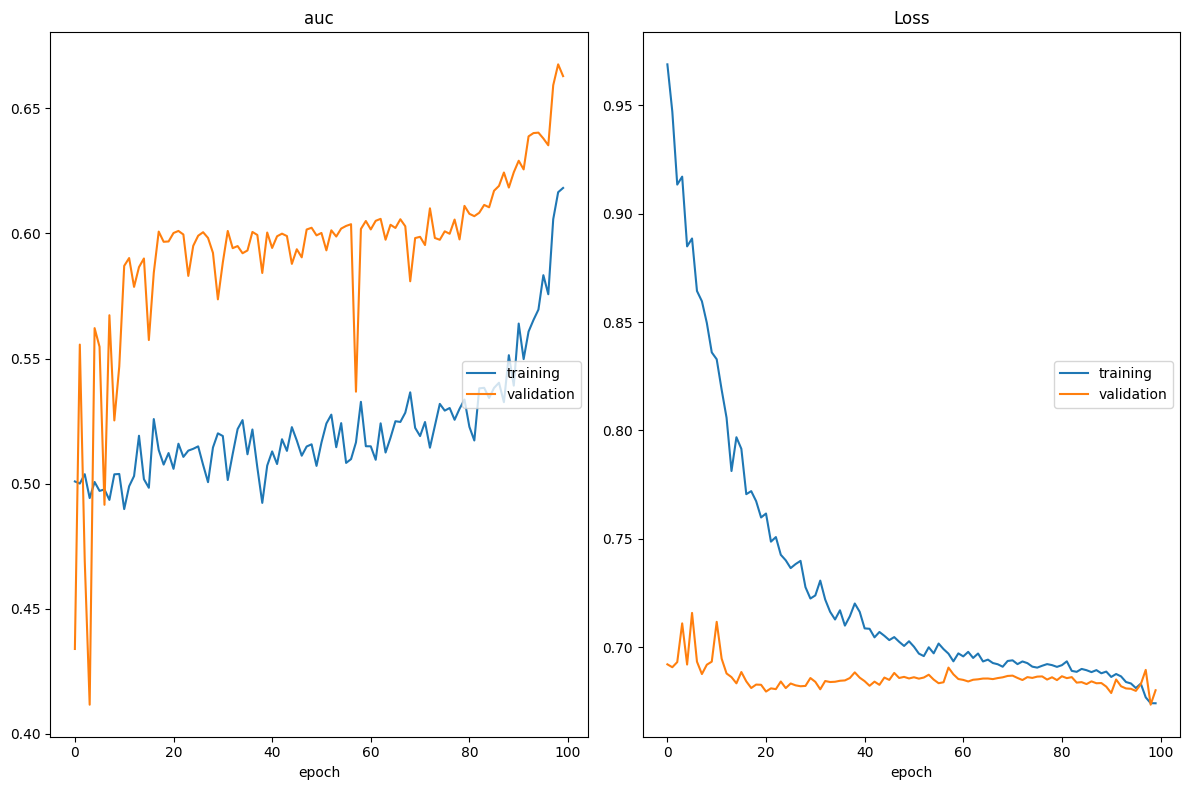

auc
	training         	 (min:    0.490, max:    0.618, cur:    0.618)
	validation       	 (min:    0.412, max:    0.668, cur:    0.663)
Loss
	training         	 (min:    0.674, max:    0.969, cur:    0.674)
	validation       	 (min:    0.673, max:    0.716, cur:    0.680)
173/173 [==============================] - 3s 16ms/step - loss: 0.6741 - auc: 0.6182 - val_loss: 0.6801 - val_auc: 0.6629


In [24]:
model.fit(X_train, y_train,
          validation_data=(X_test, y_test),
          epochs=100,
          callbacks=[PlotLossesKeras()])

Se observa en el resultado de este modelo un AUC de 61.82, se explorará otro modelo para mejorar el resultado inicial.

In [25]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.regularizers import l2

Se hace otro intento con una Red neuronal con LSTM en Keras para clasificación binaria de texto, utilizando técnicas de regularización como Dropout y L2.



In [26]:
model = Sequential()
model.add(Embedding(input_dim=len(vocabulary) + 1, output_dim=13, input_length=max_len))
model.add(LSTM(16, kernel_regularizer=l2(0.01)))  # L2 con un factor de penalización de 0.01
model.add(Dropout(0.8))  # Dropout del 50%
model.add(Dense(8, activation='relu', kernel_regularizer=l2(0.01)))  # L2 con un factor de penalización de 0.01
model.add(Dropout(0.7))  # Dropout del 50%
model.add(Dense(1, activation='sigmoid'))

# Create the optimizer
import keras.optimizers as opts
learning_rate = 0.00005
op = opts.Adam(learning_rate=learning_rate)

model.compile(loss='binary_crossentropy', optimizer=op, metrics=tf.keras.metrics.AUC())
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 818, 13)           448214    
                                                                 
 lstm (LSTM)                 (None, 16)                1920      
                                                                 
 dropout_5 (Dropout)         (None, 16)                0         
                                                                 
 dense_6 (Dense)             (None, 8)                 136       
                                                                 
 dropout_6 (Dropout)         (None, 8)                 0         
                                                                 
 dense_7 (Dense)             (None, 1)                 9         
                                                                 
Total params: 450,279
Trainable params: 450,279
Non-tr

Este código entrena un modelo de red neuronal en los datos de entrenamiento (X_train, y_train) y lo valida con los datos de prueba (X_test, y_test). Evalúa el modelo en cada época con los datos de prueba.

✅ Usa 40 épocas para aprender patrones en los datos.

✅ Divide los datos en lotes de 32 para entrenar de manera eficiente.

✅ Muestra una gráfica en tiempo real de la pérdida para analizar el proceso de entrenamiento.

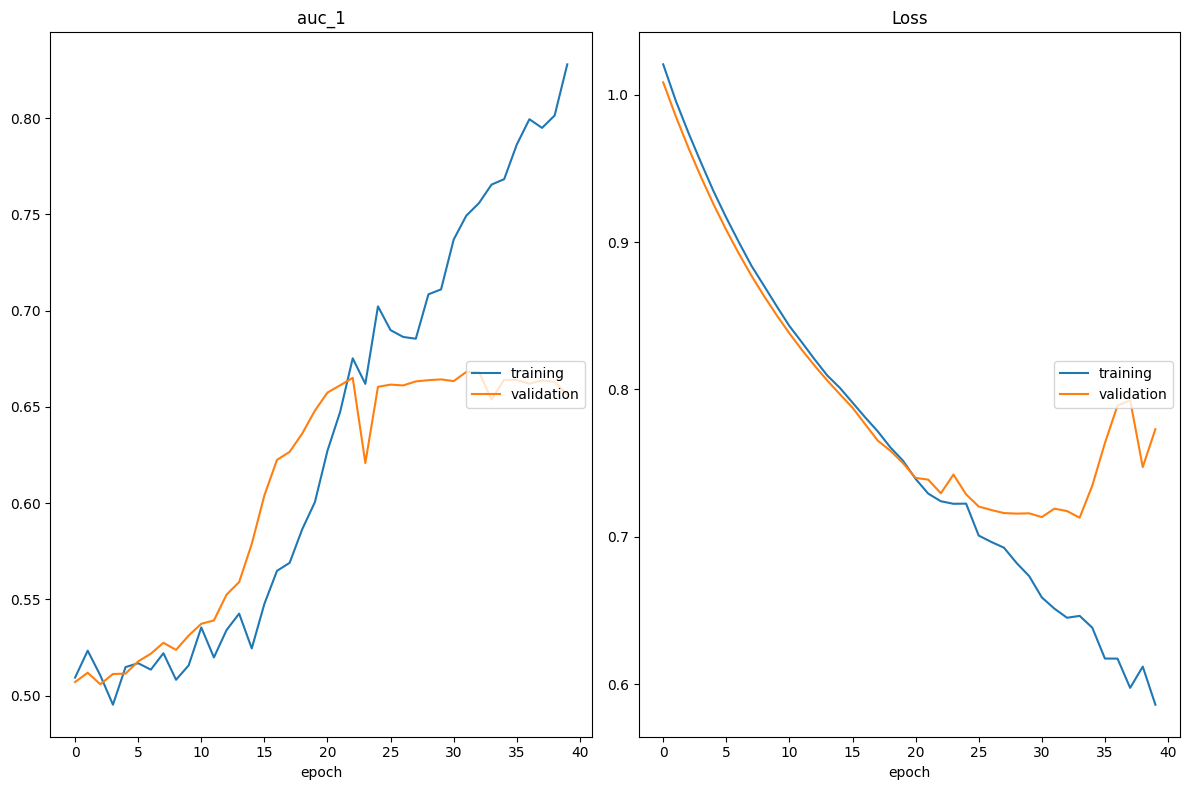

auc_1
	training         	 (min:    0.495, max:    0.828, cur:    0.828)
	validation       	 (min:    0.506, max:    0.668, cur:    0.656)
Loss
	training         	 (min:    0.586, max:    1.021, cur:    0.586)
	validation       	 (min:    0.713, max:    1.009, cur:    0.773)
173/173 [==============================] - 80s 462ms/step - loss: 0.5859 - auc_1: 0.8280 - val_loss: 0.7730 - val_auc_1: 0.6564


In [27]:
model.fit(X_train, y_train,
          validation_data=(X_test, y_test),
          epochs=40,
          batch_size=32,
          callbacks=[PlotLossesKeras()])

Se evidencia que el segundo modelo obtuvo un mejor resultado midiendolo con AUC de 82.80